In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import Functions as myfun
from scipy.stats import pearsonr
from scipy.cluster import hierarchy
import random

In [2]:
YourFolder='Alpha'
#Load Data
train_lp = pd.read_excel('../Data/'+YourFolder+'/sim_CHOlp_trainx.xlsx',index_col=0)
test_lp = pd.read_excel('../Data/'+YourFolder+'/FetIgGlp_testx.xlsx',index_col=0)
train_gp = pd.read_excel('../Data/'+YourFolder+'/CHOgp_trainy.xlsx',index_col=0)
test_gp = pd.read_excel('../Data/'+YourFolder+'/FetIgGgp_testy.xlsx',index_col=0)

Approach 1: Find simLP of BigData having a correlation above 0.9, plot their GPs as a heatmap

In [3]:
# Calculate the correlation matrix
corr_matrix = train_lp.corr()

# For each row, get the column names with correlation above 0.9
# Exclude the diagonal (self-correlation) by setting it to 0
for i in range(len(corr_matrix)):
    corr_matrix.iloc[i, i] = 0

high_corr_cols = {row: corr_matrix.columns[abs(corr_matrix.loc[row]) > 0.9].tolist() for row in corr_matrix.index}

# Sort by the length of the list of column names and get the top 3 rows
sorted_rows = sorted(high_corr_cols, key=lambda x: len(high_corr_cols[x]), reverse=True)

# # Output the results
# for row in sorted_rows:
#     print(f"Row {row} has high correlation with columns: {high_corr_cols[row]}")
high_corr_CC = high_corr_cols[sorted_rows[0]]
# high_corr_CC
# high_corr_CC.sort(reverse=True)
random.shuffle(high_corr_CC)

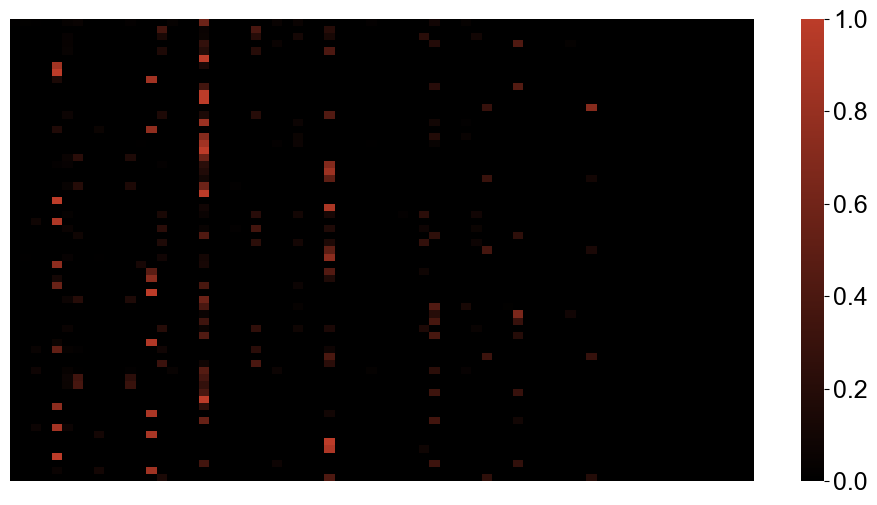

In [4]:
# Create a custom colormap with blue at the lower end and red at the upper end
colors = ["black", "#BC3C29"]
cmap = LinearSegmentedColormap.from_list("custom", colors)

plt.figure(figsize=(12, 6))
sns.heatmap(train_gp[high_corr_CC].T, annot=False, cmap=cmap, linewidths=0, linecolor='none')
# plt.title('Heatmap of DataFrame without y-axis ticks')
plt.xticks([])  # Remove y-axis ticks
plt.yticks([]) 
plt.show()

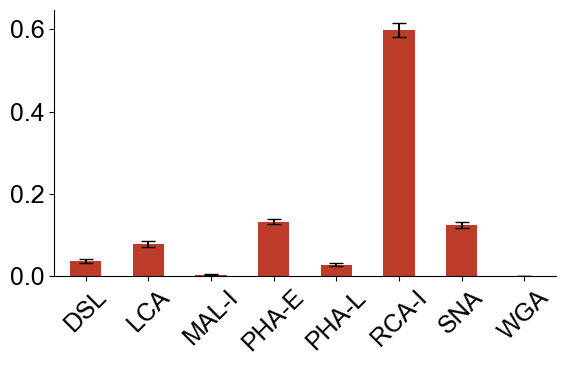

In [5]:
#Plot the lp of the grouped gp

LPs_0_df = train_lp[high_corr_CC].T
means = LPs_0_df.mean()
errors = LPs_0_df.sem()

plt.figure(figsize=(6, 4))
ax = means.plot(kind='bar', yerr=errors, capsize=5,rot=45,color=['#BC3C29'])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

Approach 2: simulate 10000 GPs and their LPs, find the similar LPs, plot GPs. 

In [6]:
#Load motif names
Bojar_motif_file = pd.read_excel("../Data/Motifs_name.xlsx",index_col=0)
#Extract only the N glycan motifs
Nglycan_motifs = Bojar_motif_file.index[Bojar_motif_file['Glycan type']=="N"]
#We use the LinearCode format
motif_linearcode = np.array(Bojar_motif_file.loc[Nglycan_motifs,'LinearCode'])
len(motif_linearcode)

32

In [7]:
#Load lectins bojar rules for N glycans -> binding rule matrix
bojar_rule = pd.read_excel("../Data/BojarBindingZscore.xlsx",index_col=0)
bojar_rule_N = bojar_rule[Nglycan_motifs] #Get N-glycofeatures only
bojar_rule_N=bojar_rule_N.sort_index()
#The lectins that we used, make sure the order of lectins are same as the measured_lp
Bojar_8Lectin_Names = ['DSL_Vector','LCA_Vector','MAL-I_Vector','PHA-E_Vector'
                       ,'PHA-L_Vector','RCAI_Vector','SNA_Vector','WGA_Vector']
bojar_8rule_N = bojar_rule_N.loc[Bojar_8Lectin_Names]
bojar_8rule_N.index = train_lp.index #Align index names
bojar_8rule_N.shape

(8, 32)

In [8]:
#Get the glycan-features df
binary_count =False
all_glycan = train_gp.index
lm = myfun.get_motif_counts(all_glycan,motif_linearcode,binary_count)
lm.columns=Nglycan_motifs
lm.columns.name=None
lm

,Terminal GlcNAca,Terminal type-II LacdiNAc,Internal Type I LacNAc,Terminal GlcNAcb,Terminal Manb,Terminal GalNAcb,Tetraantennary,"Terminal 2,3 NeuAc",Man 9,terminal Type I LacNAc,...,"Tri-antennary : b1,4",Terminal type-I LacdiNAc,Man7,Core Fucose,"a1,2 Fuc",Terminal Man1-6,terminal Type II LacNAc,Terminal GalNAca,Biantennary,Man6
Ma6(Ma3)Mb4GNb4GN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
Ma6(Ma2Ma3)Mb4GNb4GN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
Ma6(GNb2Ma3)Mb4GNb4GN,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
Ma6(Ma3)Mb4GNb4(Fa6)GN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,1,0
Ma6(Ab4GNb2Ma3)Mb4GNb4GN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0,0,0,0,0,0,1,3,0,0,...,0,0,0,1,0,0,1,0,0,0
NNa3Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0,0,0,0,0,0,1,4,0,0,...,0,0,0,1,0,0,0,0,0,0
NNa3Ab4GNb3Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4GN,0,0,0,0,0,0,1,4,0,0,...,0,0,0,0,0,0,0,0,0,0
NNa3Ab4GNb3Ab4GNb6(Ab4GNb3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0,0,0,0,0,0,1,3,0,0,...,0,0,0,1,0,0,1,0,0,0


In [9]:
#modify lm so that when ploting the heat map, we can cluster the glycans as well.
lm_plot = lm.copy()
lm_plot = lm_plot[lm_plot.columns[lm_plot.sum(0) != 0]]
lm_plot['high mannose'] = lm_plot['Man5']+lm_plot['Man6']+lm_plot['Man 8']+lm_plot['Man 9']+lm_plot['Man7 ']
lm_plot['LacNAc'] = lm_plot['Type II poly-LacNAc']+lm_plot['Internal Type II LacNAc']+lm_plot['terminal Type II LacNAc']
lm_plot['Triantennary'] = lm_plot['Tri-antennary N: b1,6']+lm_plot['Tri-antennary : b1,4']
lm_plot['Term. Mannose'] = lm_plot['Terminal Man1-2']+lm_plot['Terminal Man1-6']
lm_plot['Term. Sialic acid'] = lm_plot['Terminal 2,3 NeuAc']+lm_plot['Terminal 2,6 NeuAc']
lm_plot.drop(['Man6','Man 8','Man5','Man 9','Man7 ','Type II poly-LacNAc','Internal Type II LacNAc',
              'terminal Type II LacNAc','Tri-antennary N: b1,6','Tri-antennary : b1,4',
              'Terminal Man1-2','Terminal Man1-6','Terminal 2,6 NeuAc','Terminal 2,3 NeuAc'],axis=1,inplace=True)
lm_plot.drop(['Triantennary','Biantennary','Tetraantennary','high mannose'],axis=1,inplace=True)
(lm_plot.sum(1) == 0).any() #False
lm_plot=lm_plot.applymap(lambda x: 1 if x != 0 else 0)
print(lm_plot.sum())
print(lm_plot.sum(1))

Terminal GlcNAcb     16
Terminal b-Gal       30
Core Fucose          32
LacNAc               54
Term. Mannose        19
Term. Sialic acid    39
dtype: int64
Ma6(Ma3)Mb4GNb4GN                                                                       1
Ma6(Ma2Ma3)Mb4GNb4GN                                                                    1
Ma6(GNb2Ma3)Mb4GNb4GN                                                                   2
Ma6(Ma3)Mb4GNb4(Fa6)GN                                                                  2
Ma6(Ab4GNb2Ma3)Mb4GNb4GN                                                                3
                                                                                       ..
Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN               4
NNa3Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN           3
NNa3Ab4GNb3Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4GN         2
NNa3Ab4GNb3Ab4GNb6(Ab4GNb3Ab4GNb2

In [10]:
pd.set_option('display.max_rows', None)
sorted_data = lm_plot.sort_values(by=['LacNAc', 'Term. Sialic acid','Terminal b-Gal','Core Fucose','Term. Mannose','Terminal GlcNAcb'], 
                                  ascending=[False,False,False,False,True,True])
# sorted_data = lm_plot.sort_values(by=['Terminal GlcNAcb','Term. Mannose'], ascending=[False, True])
sorted_data
#,'Terminal b-Gal',,
# # Calculate hierarchical clustering for rows
# linkage = hierarchy.linkage(lm_plot, method='average')
# row_order = hierarchy.dendrogram(linkage, no_plot=True)['leaves']

# # Rearrange the rows based on clustering
# clustered_data = lm_plot.iloc[row_order]
# clustered_data

,Terminal GlcNAcb,Terminal b-Gal,Core Fucose,LacNAc,Term. Mannose,Term. Sialic acid
Ab4GNb2Ma6(NNa3Ab4GNb2Ma3)Mb4GNb4(Fa6)GN,0,1,1,1,0,1
Ab4GNb2Ma6(NNa6Ab4GNb2Ma3)Mb4GNb4(Fa6)GN,0,1,1,1,0,1
NNa3Ab4GNb2Ma6(Ab4GNb4(Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0,1,1,1,0,1
NNa3Ab4GNb2Ma6(NNa3Ab4GNb4(Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0,1,1,1,0,1
NNa3Ab4GNb6(Ab4GNb2)Ma6(Ab4GNb4(Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0,1,1,1,0,1
NNa3Ab4GNb6(NNa3Ab4GNb2)Ma6(Ab4GNb4(Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0,1,1,1,0,1
NNa3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0,1,1,1,0,1
Ab4GNb3Ab4GNb6(NNa3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0,1,1,1,0,1
NNa3Ab4GNb3Ab4GNb6(Ab4GNb3Ab4GNb2)Ma6(NNa3Ab4GNb4(NNa3Ab4GNb2)Ma3)Mb4GNb4(Fa6)GN,0,1,1,1,0,1
Ab4GNb2Ma6(NNa6Ab4GNb2Ma3)Mb4GNb4GN,0,1,0,1,0,1


In [11]:
#modify bojar rule
bojar_rule_z95= bojar_8rule_N.copy() # Keep p values >= 0.05
bojar_rule_z95[bojar_rule_z95<1.645] = 0

In [12]:
reg_rule = pd.read_excel('../Data/'+YourFolder+'/reg_rule.xlsx',index_col=0)


In [ ]:
#Use dirichlet distribution to simulate
starter=[1]*71
starter = np.array([[s/ sum(starter) for s in starter]])
sim_gp_arr = []
sim_lp_arr = []
i = 0
total_run=0
seed=1
model_lp = None
while i < 100:
    total_run+=1
    np.random.seed(seed)
    seed+=1
    alpha =0.9
    sim_gp = np.array([np.random.dirichlet((row/row.sum())**alpha) for row in starter])[0]
    sim_gp[sim_gp<0.01] = 0
    sim_gp*=(1/sim_gp.sum())
    # correlation = np.corrcoef(starter, FetB_data_varied)[0, 1]
    sim_lp_raw = myfun.simulate_lp(lm,bojar_rule_z95,sim_gp,False)
    sim_lp = myfun.fit_sim_lp_reg_rules(sim_lp_raw, reg_rule)
    sim_lp*=(1/sim_lp.sum())
    # glycan_lec = glycan_motif.dot(bojar_rule_z95.T)
    # lp = (glycan_lec.T).dot(gp)
    if model_lp is None:
        model_lp = sim_lp
        sim_lp_arr.append(model_lp)
    else:
        corr = abs(pearsonr(model_lp,sim_lp)[0])
        if corr>0.95:
            sim_gp_arr.append(sim_gp)
            sim_lp_arr.append(sim_lp)
            i+=1
print('100 out of '+str(total_run)+' simulated glycoprofiles have very similar lectin profile.')      


sim_gp_df = pd.DataFrame(np.array(sim_gp_arr).T,index=train_gp.index)
sim_gp_df.index.name=None
sim_gp_df.columns = [str(i) for i in range(1,len(sim_gp_df.columns)+1)]
sim_gp_df = myfun.normalize(sim_gp_df,0.02)
sim_lp_df = pd.DataFrame(np.array(sim_lp_arr).T,index=train_lp.index)
sim_lp_df.index.name=None
sim_lp_df.columns = [str(i) for i in range(1,len(sim_lp_df.columns)+1)]
###Note: uncomment below to save
# sim_gp_df.to_excel('../Data/'+YourFolder+'/sim_gp_motivation.xlsx',index = True)
# sim_gp_df.sum()
# starter
sim_gp_df = sim_gp_df.loc[sorted_data.index]

In [14]:
# get row_color for the glycans.
glycan_color=['#BC3C29', '#0072B5', '#E18727','#20854E','#7876B1','#6F99AD','#FFDC91','#EE4C97']

LacNAc_color = ['white','#0072B5']
lut1=dict(zip([0,1],LacNAc_color))
row_colors1 = sorted_data['LacNAc'].map(lut1)

T_SA_color = ['white','#E18727']
lut2=dict(zip([0,1],T_SA_color))
row_colors2 = sorted_data['Term. Sialic acid'].map(lut2)

C_Fuc_color = ['white','#7876B1']
lut3=dict(zip([0,1],C_Fuc_color))
row_colors3 = sorted_data['Core Fucose'].map(lut3)

T_Gal_color = ['white','#20854E']
lut4=dict(zip([0,1],T_Gal_color))
row_colors4 = sorted_data['Terminal b-Gal'].map(lut4)

T_GN_color = ['white','#6F99AD']
lut5=dict(zip([0,1],T_GN_color))
row_colors5 = sorted_data['Terminal GlcNAcb'].map(lut5)

T_Man_color = ['white','#FFDC91']
lut6=dict(zip([0,1],T_Man_color))
row_colors6 = sorted_data['Term. Mannose'].map(lut6)

col_colors = pd.concat([row_colors1,row_colors2,row_colors4,row_colors3,row_colors5,row_colors6],axis=1)

/Users/hainingli/opt/anaconda3/lib/python3.9/site-packages/seaborn/matrix.py:1203: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(**tight_params)


<Figure size 800x1000 with 0 Axes>

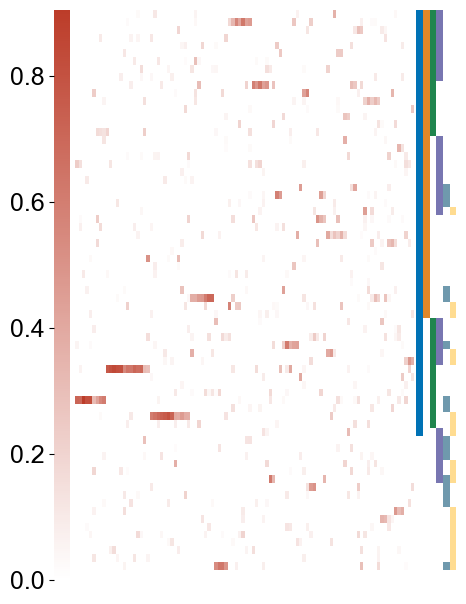

In [15]:
# Create a custom colormap with blue at the lower end and red at the upper end
colors = ["white", "#BC3C29"]
cmap = LinearSegmentedColormap.from_list("custom", colors)

plt.figure(figsize=(8,10))
# sns.heatmap(sim_gp_df.T, annot=False, cmap=cmap, linewidths=0, linecolor='none')
# plt.title('Heatmap of DataFrame without y-axis ticks')
g = sns.clustermap(sim_gp_df, cmap=cmap, row_colors=col_colors,linewidths=0, figsize=(8, 10), method='complete', row_cluster=False)

g.ax_heatmap.set_xticks([])   # Remove y-axis ticks
g.ax_heatmap.set_yticks([]) 
g.ax_col_dendrogram.set_visible(False) #remove the dendrogram label
g.ax_row_dendrogram.set_visible(False) #remove the dendrogram label

#adjust the legend color bar 
x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([0.45, 0.1, 0.02, 0.57])
g.ax_cbar.tick_params(left=True,right=False,labelleft=True,labelright=False)

#adjust the col_color position
ax_col_colors = g.ax_row_colors
box = ax_col_colors.get_position()
# box_heatmap = g.ax_heatmap.get_position()
ax_col_colors.set_position([box.x0+0.595, box.y0, 0.05, box.height])
ax_col_colors.set_xticklabels([])
ax_col_colors.xaxis.set_tick_params(size=0) #remove the tick marks (- sign) 
plt.show()

/Users/hainingli/opt/anaconda3/lib/python3.9/site-packages/seaborn/matrix.py:1203: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(**tight_params)


<Figure size 1800x1200 with 0 Axes>

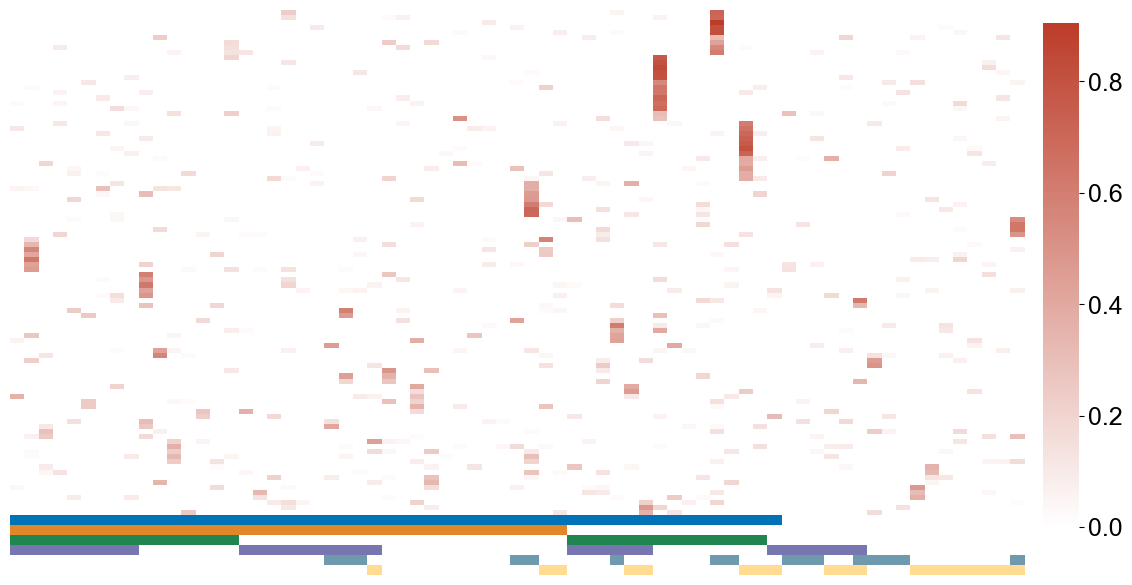

In [16]:
# Create a custom colormap with blue at the lower end and red at the upper end
colors = ["white", "#BC3C29"]
cmap = LinearSegmentedColormap.from_list("custom", colors)

plt.figure(figsize=(18, 12))
# sns.heatmap(sim_gp_df.T, annot=False, cmap=cmap, linewidths=0, linecolor='none')
# plt.title('Heatmap of DataFrame without y-axis ticks')
g = sns.clustermap(sim_gp_df.T, cmap=cmap, col_colors=col_colors,linewidths=0, figsize=(18, 12), method='complete', col_cluster=False)

g.ax_heatmap.set_xticks([])   # Remove y-axis ticks
g.ax_heatmap.set_yticks([]) 
g.ax_row_dendrogram.set_visible(False) #remove the dendrogram label
g.ax_col_dendrogram.set_visible(False) #remove the dendrogram label

#adjust the legend color bar 
x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([0.91, 0.1, 0.02, 0.42])

#adjust the col_color position
ax_col_colors = g.ax_col_colors
box = ax_col_colors.get_position()
box_heatmap = g.ax_heatmap.get_position()
ax_col_colors.set_position([box.x0, box_heatmap.y0-0.05, box.width, 0.05])
ax_col_colors.set_yticklabels([])
ax_col_colors.yaxis.set_tick_params(size=0) #remove the tick marks (- sign) 
plt.show()

<Figure size 1800x1200 with 0 Axes>

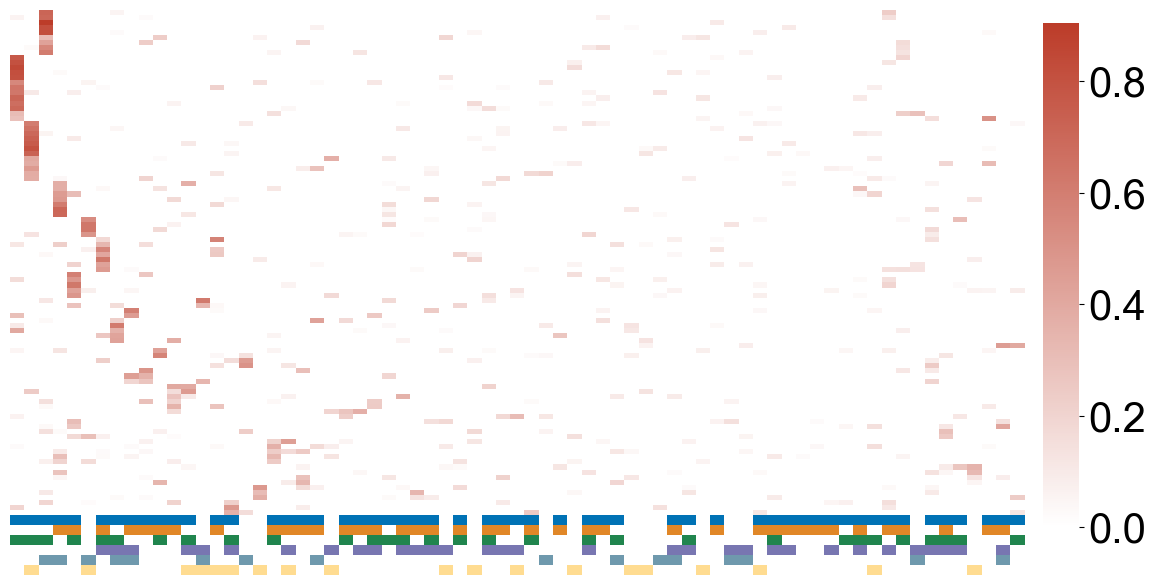

In [17]:
# Create a custom colormap with blue at the lower end and red at the upper end
colors = ["white", "#BC3C29"]
cmap = LinearSegmentedColormap.from_list("custom", colors)

plt.figure(figsize=(18, 12))
# sns.heatmap(sim_gp_df.T, annot=False, cmap=cmap, linewidths=0, linecolor='none')
# plt.title('Heatmap of DataFrame without y-axis ticks')
g = sns.clustermap(sim_gp_df.T, cmap=cmap, col_colors=col_colors,linewidths=0, figsize=(18, 12), method='complete')#, col_cluster=False)

g.ax_heatmap.set_xticks([])   # Remove y-axis ticks
g.ax_heatmap.set_yticks([]) 
g.ax_row_dendrogram.set_visible(False) #remove the dendrogram label
g.ax_col_dendrogram.set_visible(False) #remove the dendrogram label

#adjust the legend color bar 
x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([0.91, 0.1, 0.02, 0.42])
g.ax_cbar.tick_params(labelsize=30)

#adjust the col_color position
ax_col_colors = g.ax_col_colors
box = ax_col_colors.get_position()
box_heatmap = g.ax_heatmap.get_position()
ax_col_colors.set_position([box.x0, box_heatmap.y0-0.05, box.width, 0.05])
ax_col_colors.set_yticklabels([])
ax_col_colors.yaxis.set_tick_params(size=0) #remove the tick marks (- sign) 
plt.show()

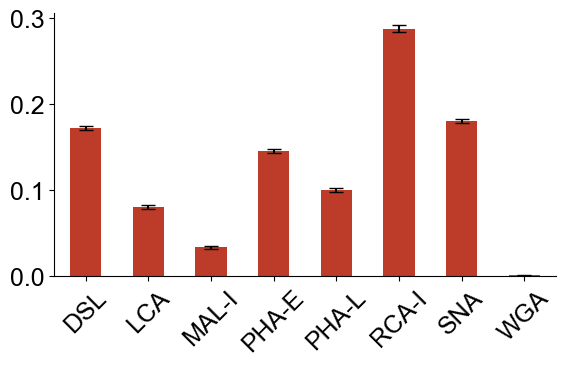

In [18]:
#Plot the lp of the grouped gp

LPs_0_df = sim_lp_df.T
means = LPs_0_df.mean()
errors = LPs_0_df.sem()

plt.figure(figsize=(6, 4))
ax = means.plot(kind='bar', yerr=errors, capsize=5,rot=45,color=['#BC3C29'])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

In [20]:
sim_lp
sim_lp_raw
sim_lp_df.corr()
# pearsonr(sim_lp_raw, sim_lp)[0]
LPs_0_df.T.corr()

,1,2,3,4,5,6,7,8,9,10,...,92,93,94,95,96,97,98,99,100,101
1,1.000000,0.964205,0.970598,0.952996,0.966922,0.976074,0.975171,0.981549,0.967079,0.976153,...,0.970539,0.956890,0.973995,0.980387,0.954707,0.952806,0.959816,0.955601,0.957346,0.974063
2,0.964205,1.000000,0.966506,0.964057,0.985991,0.962427,0.965436,0.945428,0.993757,0.918602,...,0.901218,0.952820,0.921271,0.965665,0.971252,0.908682,0.869549,0.971133,0.967189,0.910701
3,0.970598,0.966506,1.000000,0.911939,0.987514,0.998657,0.967957,0.947869,0.973483,0.927249,...,0.943849,0.960554,0.979305,0.972697,0.980543,0.904522,0.940777,0.972313,0.976118,0.954220
4,0.952996,0.964057,0.911939,1.000000,0.927925,0.912967,0.943561,0.918106,0.973814,0.910891,...,0.872529,0.881812,0.879504,0.962536,0.943358,0.870941,0.853004,0.949331,0.907905,0.897484
5,0.966922,0.985991,0.987514,0.927925,1.000000,0.986600,0.973243,0.961364,0.980109,0.931724,...,0.927011,0.978337,0.955938,0.966844,0.979721,0.922800,0.906893,0.978107,0.966592,0.940181
6,0.976074,0.962427,0.998657,0.912967,0.986600,1.000000,0.975073,0.955498,0.969185,0.942271,...,0.955263,0.961889,0.987004,0.977735,0.981032,0.911289,0.953599,0.974940,0.972375,0.967348
7,0.975171,0.965436,0.967957,0.943561,0.973243,0.975073,1.000000,0.951066,0.965456,0.973078,...,0.945969,0.932033,0.967330,0.989409,0.982584,0.892860,0.939896,0.987857,0.959135,0.975654
8,0.981549,0.945428,0.947869,0.918106,0.961364,0.955498,0.951066,1.000000,0.935674,0.965094,...,0.947467,0.980634,0.952645,0.940442,0.921653,0.982964,0.940733,0.927066,0.912917,0.960730
9,0.967079,0.993757,0.973483,0.973814,0.980109,0.969185,0.965456,0.935674,1.000000,0.912181,...,0.902293,0.936379,0.929157,0.977983,0.982193,0.889424,0.883225,0.979135,0.965503,0.918187
10,0.976153,0.918602,0.927249,0.910891,0.931724,0.942271,0.973078,0.965094,0.912181,1.000000,...,0.976474,0.925461,0.963445,0.959984,0.921842,0.933955,0.960108,0.932114,0.921919,0.981091


In [21]:
sim_lp_df = myfun.simulate_lp(lm,bojar_rule_z95,sim_gp_df,False)

In [22]:
corr2_matrix = sim_lp_df.corr()

# Identify pairs of samples with a correlation above 0.9
# (excluding self-correlation)
pairs = []
for i in range(corr2_matrix.shape[0]):
    for j in range(i+1, corr2_matrix.shape[1]):
        if corr2_matrix.iloc[i, j] > 0.9:
            pairs.append((corr2_matrix.columns[i], corr2_matrix.columns[j]))

# Group these samples
groups2 = []
while pairs:
    current_group = [pairs[0][0], pairs[0][1]]
    pairs.pop(0)
    for pair in pairs.copy():
        if pair[0] in current_group or pair[1] in current_group:
            current_group.append(pair[0])
            current_group.append(pair[1])
            pairs.remove(pair)
    groups2.append(list(set(current_group)))

print(len(groups2))

2


A visulization of BigData

In [5]:
CHO_gp = pd.read_excel('../Data/glycoprofile_Voldborg.xlsx', index_col = 0)
CHO_genotypes = CHO_gp.loc['genotypes']
CHO_proteins = CHO_gp.loc['protein']
CHO_gp.drop(['genotypes','protein'],axis = 0,inplace=True)
CHO_gp = CHO_gp.astype(float)
CHO_gp.shape

(68, 309)

In [6]:
len(CHO_genotypes.unique())
len(CHO_proteins.unique())


10

In [7]:
CHO_genotypes_colors = [
    "#FF6347",  # Tomato
    "#FFD700",  # Gold
    "#4682B4",  # Steel Blue
    "#008080",  # Teal
    "#20B2AA",  # Light Sea Green
    "#9400D3",  # Dark Violet
    "#8B4513",  # Saddle Brown
    "#FF69B4",  # Hot Pink
    "#A0522D",  # Sienna
    "#778899",  # Light Slate Gray
]

CHO_proteins_colors = [
    "#7FFF00",  # Chartreuse
    "#D2691E",  # Chocolate
    "#6495ED",  # Cornflower Blue
    "#DC143C",  # Crimson
    "#006400",  # Dark Green
    "#4B0082",  # Indigo
    "#F08080",  # Light Coral
    "#000080",  # Navy
    "#9ACD32",  # Yellow Green
    "#FFA500",  # Orange
]

lut1=dict(zip(CHO_genotypes.unique(),CHO_genotypes_colors))
gt_colors1 = CHO_genotypes.map(lut1)

lut_protein=dict(zip(CHO_proteins.unique(),CHO_proteins_colors))
protein_colors1 = CHO_proteins.map(lut_protein)
info_colors = pd.concat([gt_colors1,protein_colors1])

In [12]:
lm_CHO = myfun.get_motif_counts(CHO_gp.index,motif_linearcode,False)
lm_CHO.columns=Nglycan_motifs
lm_CHO.columns.name=None

#modify lm so that when ploting the heat map, we can cluster the glycans as well.
lm_plot = lm_CHO.copy()
lm_plot = lm_plot[lm_plot.columns[lm_plot.sum(0) != 0]]
lm_plot['high mannose'] = lm_plot['Man5']+lm_plot['Man6']+lm_plot['Man 8']+lm_plot['Man 9']+lm_plot['Man7 ']
lm_plot['LacNAc'] = lm_plot['Type II poly-LacNAc']+lm_plot['Internal Type II LacNAc']+lm_plot['terminal Type II LacNAc']
lm_plot['Triantennary'] = lm_plot['Tri-antennary N: b1,6']+lm_plot['Tri-antennary : b1,4']
lm_plot['Term. Mannose'] = lm_plot['Terminal Man1-2']+lm_plot['Terminal Man1-6']
lm_plot['Term. Sialic acid'] = lm_plot['Terminal 2,3 NeuAc']+lm_plot['Terminal 2,6 NeuAc']
lm_plot.drop(['Man6','Man 8','Man5','Man 9','Man7 ','Type II poly-LacNAc','Internal Type II LacNAc',
              'terminal Type II LacNAc','Tri-antennary N: b1,6','Tri-antennary : b1,4',
              'Terminal Man1-2','Terminal Man1-6','Terminal 2,6 NeuAc','Terminal 2,3 NeuAc'],axis=1,inplace=True)
lm_plot.drop(['Triantennary','Biantennary','Tetraantennary','high mannose'],axis=1,inplace=True)


In [17]:
# get row_color for the glycans.
glycan_color=['#BC3C29', '#0072B5', '#E18727','#20854E','#7876B1','#6F99AD','#FFDC91','#EE4C97']
sorted_data = lm_plot.sort_values(by=['LacNAc', 'Term. Sialic acid','Terminal b-Gal','Core Fucose','Term. Mannose','Terminal GlcNAcb'], 
                                  ascending=[False,False,False,False,True,True])

LacNAc_color = ['white','#0072B5']
lut1=dict(zip([0,1],LacNAc_color))
row_colors1 = sorted_data['LacNAc'].map(lut1)

T_SA_color = ['white','#E18727']
lut2=dict(zip([0,1],T_SA_color))
row_colors2 = sorted_data['Term. Sialic acid'].map(lut2)

C_Fuc_color = ['white','#7876B1']
lut3=dict(zip([0,1],C_Fuc_color))
row_colors3 = sorted_data['Core Fucose'].map(lut3)

T_Gal_color = ['white','#20854E']
lut4=dict(zip([0,1],T_Gal_color))
row_colors4 = sorted_data['Terminal b-Gal'].map(lut4)

T_GN_color = ['white','#6F99AD']
lut5=dict(zip([0,1],T_GN_color))
row_colors5 = sorted_data['Terminal GlcNAcb'].map(lut5)

T_Man_color = ['white','#FFDC91']
lut6=dict(zip([0,1],T_Man_color))
row_colors6 = sorted_data['Term. Mannose'].map(lut6)
# display(row_colors6)
glycan_colors = pd.concat([row_colors1,row_colors2,row_colors4,row_colors3,row_colors5,row_colors6],axis=1)
# glycan_colors

In [29]:
CHO_gp
# CHO_gp/(CHO_gp.max())

,CC005,CC006,CC008,CC009,CC010,CC011,CC016,CC017,CC019,CC020,...,CC550,CC551,CC552,CC553,CC554,CC555,CC556,CC558,CC559,CC560
Ma6(GNb2Ma3)Mb4GNb4GN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.017781,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Ma6(GNb2Ma3)Mb4GNb4(Fa6)GN,0.019233,0.010740,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Ma6(Ab4GNb2Ma3)Mb4GNb4(Fa6)GN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Ma6(Ma3)Ma6(Ab4GNb2Ma3)Mb4GNb4(Fa6)GN,0.000000,0.000000,0.000000,0.000000,0.020683,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Ma6(NNa3Ab4GNb2Ma3)Mb4GNb4(Fa6)GN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Ma6(Ab4GNb2Ma3)Mb4GNb4GN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Ma3Ma6(Ab4GNb2Ma3)Mb4GNb4GN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Ma6(Ma3)Ma6(Ab4GNb2Ma3)Mb4GNb4GN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.014652,0.021730,0.000000,0.000000,0.000000
Ma6(NNa3Ab4GNb2Ma3)Mb4GNb4GN,0.000000,0.177095,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Ma3Ma6(NNa3Ab4GNb2Ma3)Mb4GNb4GN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


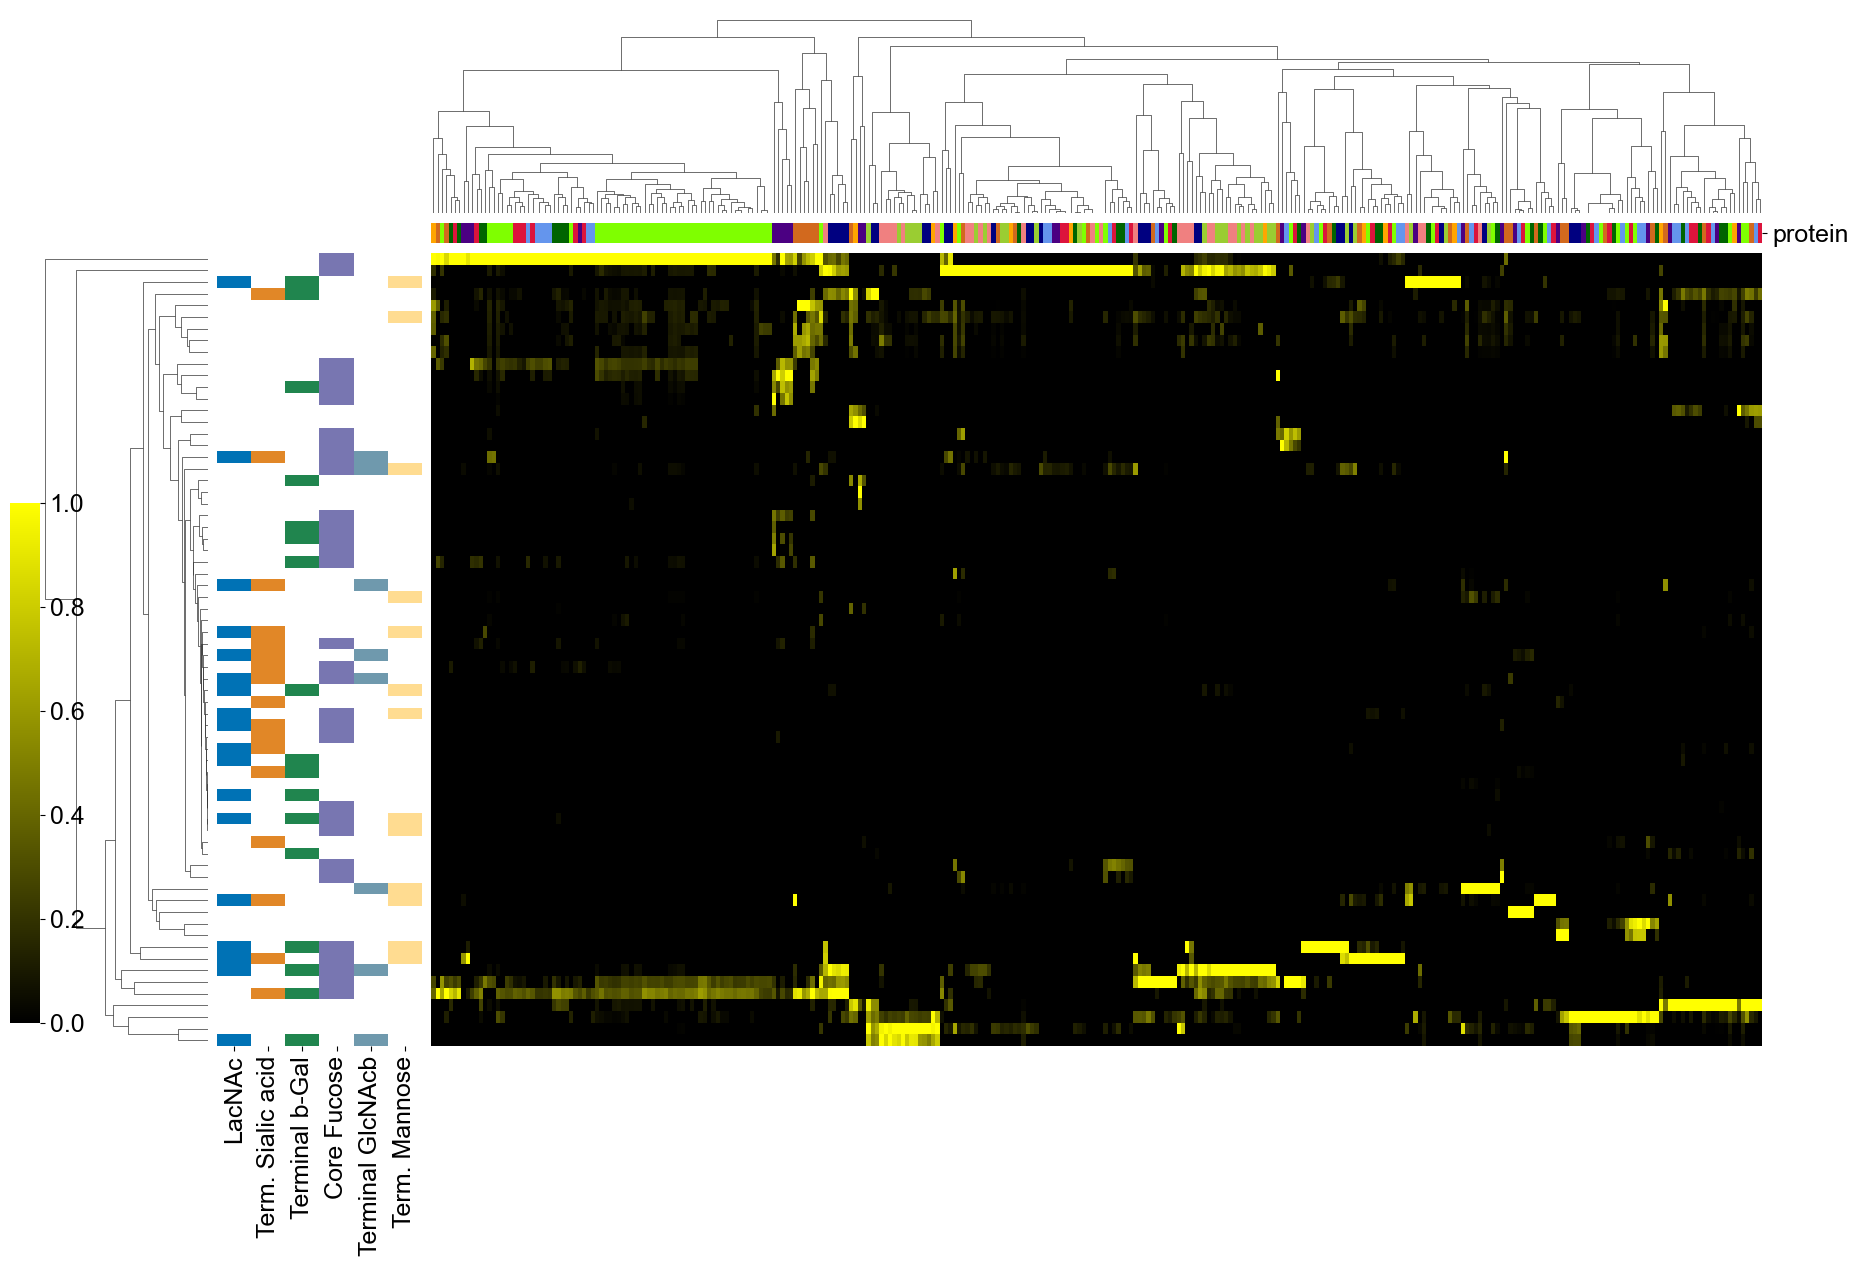

In [38]:
CHO_gp_log10 = np.log10(CHO_gp.clip(lower=1e-10))  # Use clip to avoid log10(0) for any zero values.
CHO_gp_1 = CHO_gp/(CHO_gp.max())
colors = ["black", "yellow"]#["white", "#BC3C29"]
cmap = LinearSegmentedColormap.from_list("custom", colors)

g = sns.clustermap(
    CHO_gp_1,
    cmap=cmap,
    col_colors=protein_colors1,
    row_colors=glycan_colors,
    linewidths=0,
    figsize=(30, 13),  # Adjusted for more width
    method='complete',
    colors_ratio=0.02,
    dendrogram_ratio=(.1, .2),  # Example ratios, adjust as needed
    cbar_pos=(0, .2, .01, .4)  # Example position, adjust as needed
)
g.ax_heatmap.set_xticks([])   # Remove y-axis ticks
g.ax_heatmap.set_yticks([]) 

# ax_row_colors = g.ax_row_colors
# box = ax_row_colors.get_position()
# ax_row_colors.set_position([box.x0+box.width*0.5, box.y0, box.width*0.5, box.height])


# # Draw the rest of the plot
plt.show()



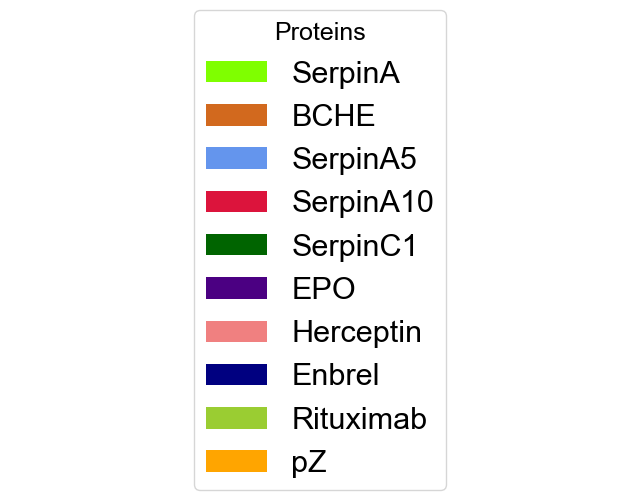

In [80]:
from matplotlib.patches import Patch
# Create a list of patch handles
handles = [Patch(facecolor=lut_protein[name]) for name in lut_protein]

#Create the legend, specifying the anchor and location
plt.figure(figsize=(8, 3))
plt.legend(
    handles=handles,
    labels=lut_protein.keys(),
    title='Proteins',
    loc='center',  # Position the legend at the center of the figure
)

# Hide the axes
plt.gca().set_axis_off()

# Show the figure
plt.show()

In [81]:
#Now, plot the 30 genotypes.
gt_category_df = pd.read_excel('../Data/BigData_Genotype_category.xlsx',index_col=0)
gt_category_df.shape #20,30
gt_category_df = gt_category_df.T
# display(gt_category_df)
gt_category_df['B4galt1/2/3'] = gt_category_df['B4galt1']
gt_category_df.drop(['B4galt1','B4galt2','B4galt3'],axis=1,inplace=True)
gt_category_df['Mgat4a/b'] = gt_category_df['Mgat4a']
gt_category_df.drop(['Mgat4b','Mgat4a'],axis=1,inplace=True)
gt_category_df['St3Gal3/4/6'] = gt_category_df['St3Gal3']
gt_category_df.drop(['St3Gal3','St3Gal4','St3Gal6'],axis=1,inplace=True)
gt_category_df['St3gal3/4/6'] = gt_category_df['St3gal3']
gt_category_df.drop(['St3gal3','St3gal4','St3gal6'],axis=1,inplace=True)
gt_category_df.shape


(30, 13)

In [106]:
# get row_color for the gts.
color_list = ['#1f77b4', 
              '#aec7e8', 
              '#ff7f0e', 
              '#ffbb78', 
              '#2ca02c', 
              '#98df8a', 
              '#d62728', 
              '#ff9896', 
              '#9467bd', 
              '#c5b0d5', 
              '#8c564b', 
              '#c49c94', 
              '#e377c2']

gt_colors_list = []
for index,gt in enumerate(gt_category_df.columns):
    color = ['black','white',color_list[index]]
    # print(color)
    lut=dict(zip([1,0,-1],color))
    # display(gt_category_df[gt].map(lut))
    gt_colors_list.append(gt_category_df[gt].map(lut))
    # gt_colors_list+=gt_category_df[gt].map(lut)
# gt_colors = pd.concat(gt_colors_list,axis=1)
gt_colors = pd.DataFrame(gt_colors_list)
gt_colors = gt_colors.T 
# gt_colors = gt_colors.astype('color')
gt_colors

,B3gnt2,B4galt4,B4galt5,Fut8,Mgat2,Mgat5,Sppl3,St6gal1,WT,B4galt1/2/3,Mgat4a/b,St3Gal3/4/6,St3gal3/4/6
WT,white,white,white,white,white,white,white,white,#9467bd,white,white,white,white
"B3gnt2,Fut8,Mgat4a/4b/5,Sppl3,St3gal3/4/6(St6gal1)",#1f77b4,white,white,#ffbb78,white,#98df8a,#d62728,black,white,white,#8c564b,white,#e377c2
"Mgat5,Fut8,St3Gal3/4/6,B3gnt2,Sppl3",#1f77b4,white,white,#ffbb78,white,#98df8a,#d62728,white,white,white,white,#c49c94,white
"Mgat2,Fut8,B4galt1/2/3",white,white,white,#ffbb78,#2ca02c,white,white,white,white,#c5b0d5,white,white,white
"Mgat4a/4b/5,Fut8,B3gnt2,Sppl3",#1f77b4,white,white,#ffbb78,white,#98df8a,#d62728,white,white,white,#8c564b,white,white
B4galt1/2/3,white,white,white,white,white,white,white,white,white,#c5b0d5,white,white,white
"B3gnt2,Sppl3",#1f77b4,white,white,white,white,white,#d62728,white,white,white,white,white,white
"Mgat2,Fut8,B3gnt2,Sppl3",#1f77b4,white,white,#ffbb78,#2ca02c,white,#d62728,white,white,white,white,white,white
St3gal3/4/6(St6gal1),white,white,white,white,white,white,white,black,white,white,white,white,#e377c2
"Mgat5,St3gal3/4/6,B3gnt2,Sppl3",#1f77b4,white,white,white,white,#98df8a,#d62728,white,white,white,white,white,#e377c2


In [107]:
# Create a mapping from 'A' to 'B', assuming df_B has a column 'A_Index' which corresponds to 'A'
# mapping = CHO_gp['A_Index'].to_dict()

# # Replace the values in df_B using the mapping and values from df_A
# df_B['Value'] = df_B['A_Index'].map(df_A['Value'])
CHO_genotypes
gt_colors_df_whole = pd.DataFrame(0,index=CHO_gp.columns,columns=gt_colors.columns)
for col in gt_colors_df_whole.columns:
    for ind in gt_colors.index:
        whole_ind = CHO_genotypes[CHO_genotypes == ind].index.to_numpy()
        # print(whole_ind)
        gt_colors_df_whole.loc[whole_ind,col] = gt_colors.loc[ind,col]

# gt_colors_df_whole


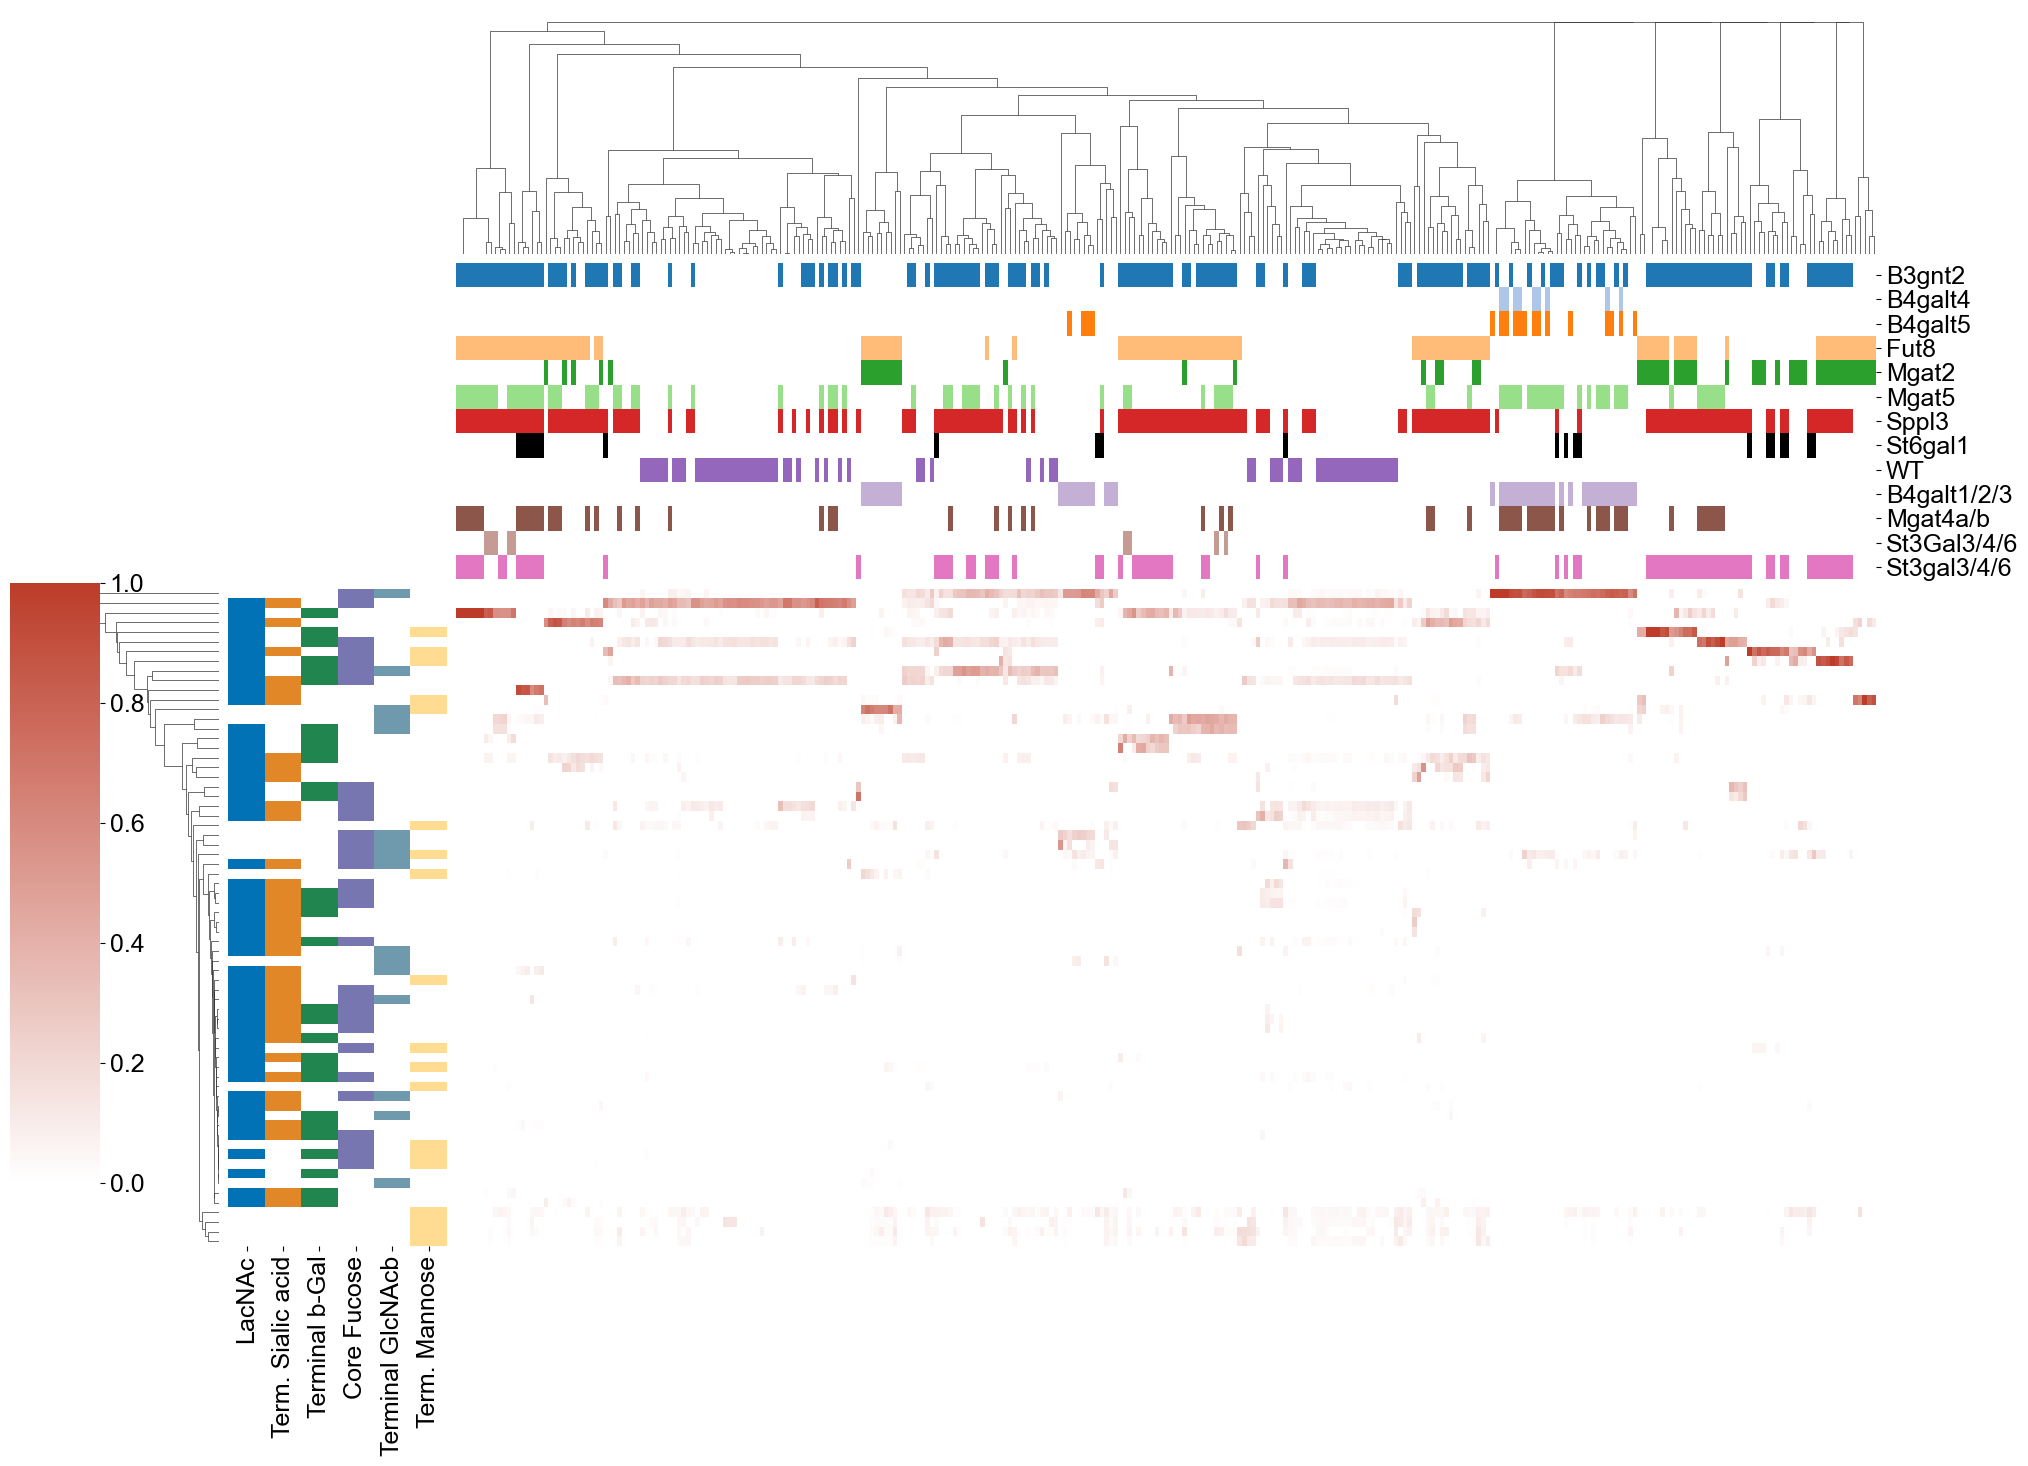

In [118]:
g = sns.clustermap(
    CHO_gp, 
    cmap=cmap,
    col_colors=gt_colors_df_whole, 
    row_colors=glycan_colors,
    linewidths=0, 
    figsize=(30, 15),  # Adjusted for more width
    method='complete',
    colors_ratio=0.02,
    dendrogram_ratio=(.1, .2),  # Example ratios, adjust as needed
    cbar_pos=(0, .2, .03, .4)  # Example position, adjust as needed
)
g.ax_heatmap.set_xticks([])   # Remove y-axis ticks
g.ax_heatmap.set_yticks([]) 

# ax_row_colors = g.ax_row_colors
# box = ax_row_colors.get_position()
# ax_row_colors.set_position([box.x0+box.width*0.5, box.y0, box.width*0.5, box.height])


# # Draw the rest of the plot
plt.show()



In [109]:
import matplotlib.pyplot as plt

# Select a colormap with distinctive colors
colormap = plt.cm.tab20

# Generate 13 distinctive colors from the colormap
colors = [colormap(i/20) for i in range(13)]

# Convert RGBA colors to hex format without alpha value
hex_colors = ['#%02x%02x%02x' % (int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255)) for rgb in colors]

# Remove the '#' to only have the 6-digit index
color_indexes = [hex_color[1:] for hex_color in hex_colors]

print(color_indexes)



['1f77b4', 'aec7e8', 'ff7f0e', 'ffbb78', '2ca02c', '98df8a', 'd62728', 'ff9896', '9467bd', 'c5b0d5', '8c564b', 'c49c94', 'e377c2']


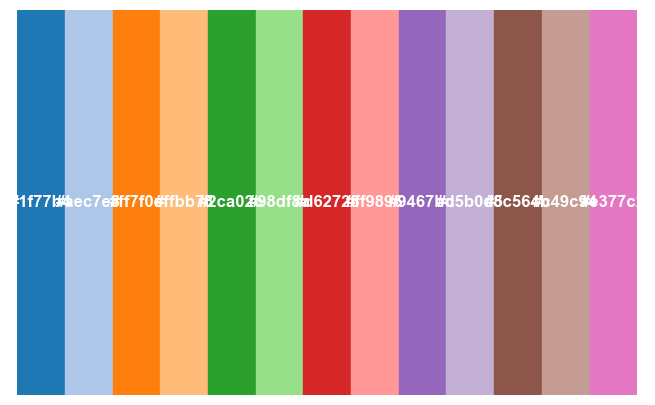

In [105]:
import matplotlib.pyplot as plt

# Select a colormap with distinctive colors
colormap = plt.cm.tab20

# Generate 13 distinctive colors from the colormap
colors = [colormap(i/20) for i in range(13)]

# Convert RGBA colors to hex format without alpha value
hex_colors = ['#%02x%02x%02x' % (int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255)) for rgb in colors]

# Create a figure and a subplot
fig, ax = plt.subplots(figsize=(8, 5))

# Display each color as a rectangle in the plot
for i, color in enumerate(hex_colors):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
    ax.annotate(color, (i+0.5, 0.5), color='w', weight='bold', 
                fontsize=12, ha='center', va='center')

# Set the limits of the plot to show all rectangles
ax.set_xlim(0, 13)
ax.set_ylim(0, 1)

# Remove the axes for a cleaner look
ax.axis('off')

# Show the plot
plt.show()
